# FRQI / NEQR Encoding — Working Implementation

Implements and verifies pixel-to-qubit encoding for both FRQI and NEQR on a small
grayscale patch, then compares qubit count, circuit depth, and gate count.

**Status: implemented and verified (Jul 28).** Both encodings tested against a
4-pixel patch and confirmed to reconstruct correct values via simulation.

In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import RYGate, XGate
from qiskit_aer import AerSimulator
from qiskit import transpile
import numpy as np

## 1. Sample patch

Synthetic 2x2 grayscale patch for now — swap this out for a real document image
crop once data is available (see `data/README.md`).

In [2]:
patch = np.array([
    [0, 255],
    [128, 64]
])
print(patch)

[[  0 255]
 [128  64]]


## 2. FRQI Encoding

One color qubit whose rotation angle encodes the pixel value, entangled with
position qubits that encode the pixel's index.

For pixel `i` with normalized angle `theta_i = (pi/2) * pixel_value/255`:
apply a controlled-RY(2*theta_i) on the color qubit, controlled on the position
register equaling `|i>`. We flip the 0-bits of `i` to 1 with X gates so the
multi-controlled gate fires only on that exact position, apply the rotation,
then undo the X-flips.

Position qubits: 2, total qubits: 3
Angles (radians): [0.    1.571 0.788 0.394]


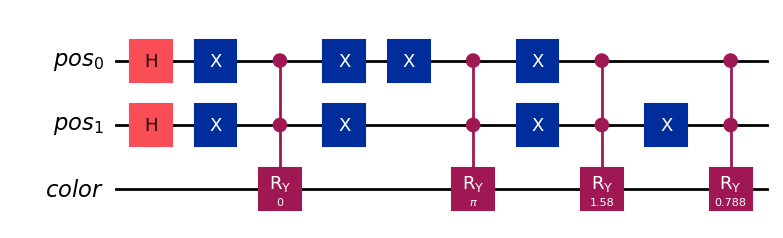

In [3]:
def build_frqi_circuit(patch):
    flat = patch.flatten()
    n_pixels = len(flat)
    n_pos_qubits = int(np.ceil(np.log2(n_pixels)))
    angles = (np.pi / 2) * (flat / 255.0)

    pos = QuantumRegister(n_pos_qubits, 'pos')
    color = QuantumRegister(1, 'color')
    qc = QuantumCircuit(pos, color)

    qc.h(pos)  # uniform superposition over all pixel positions

    for i, theta in enumerate(angles):
        bin_str = format(i, f'0{n_pos_qubits}b')  # MSB-first index of pixel i

        for j, bit in enumerate(bin_str):
            if bit == '0':
                qc.x(pos[j])

        if n_pos_qubits > 0:
            gate = RYGate(2 * theta).control(n_pos_qubits)
            qc.append(gate, list(pos) + [color[0]])
        else:
            qc.ry(2 * theta, color[0])

        for j, bit in enumerate(bin_str):
            if bit == '0':
                qc.x(pos[j])

    return qc, n_pos_qubits, angles

frqi_qc, n_pos, angles = build_frqi_circuit(patch)
print(f"Position qubits: {n_pos}, total qubits: {n_pos + 1}")
print(f"Angles (radians): {np.round(angles, 3)}")
frqi_qc.draw('mpl')

## 3. NEQR Encoding

Exact binary grayscale value per pixel (8 qubits for 0-255), entangled with
position qubits. Same position-flip trick as FRQI, but instead of one rotation
we apply a multi-controlled X for each '1' bit in the pixel's exact binary
value.

Position qubits: 2, color qubits: 8, total: 10


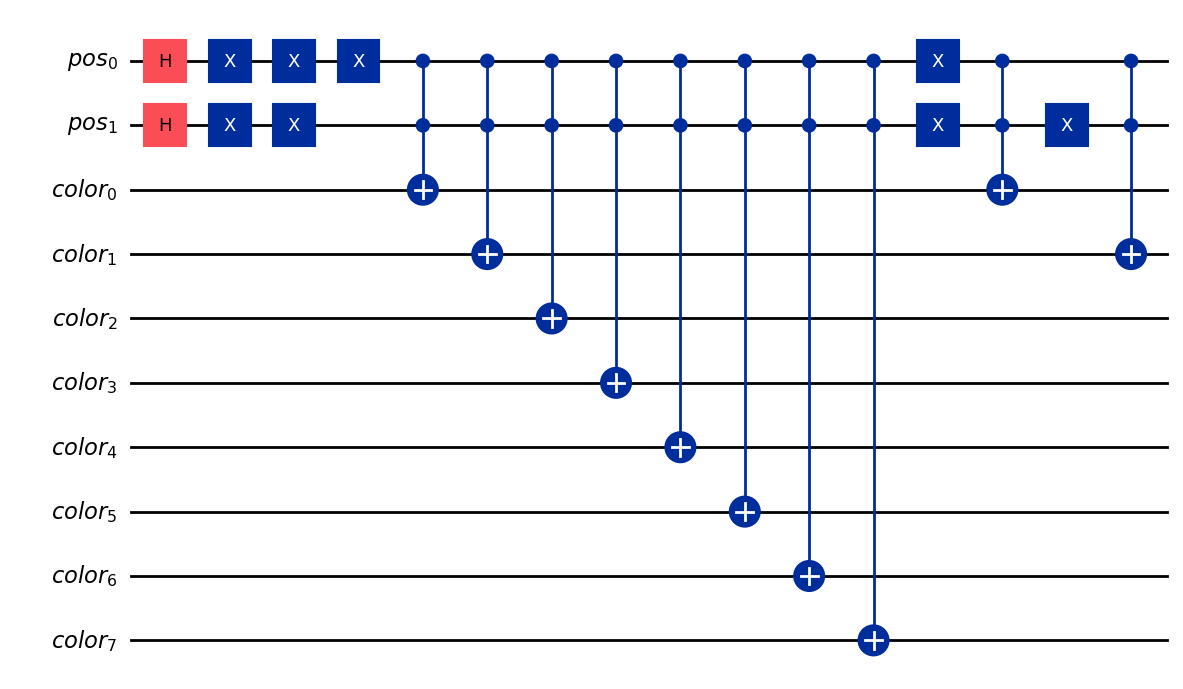

In [4]:
def build_neqr_circuit(patch, bit_depth=8):
    flat = patch.flatten()
    n_pixels = len(flat)
    n_pos_qubits = int(np.ceil(np.log2(n_pixels)))

    pos = QuantumRegister(n_pos_qubits, 'pos')
    color = QuantumRegister(bit_depth, 'color')
    qc = QuantumCircuit(pos, color)

    qc.h(pos)

    for i, val in enumerate(flat):
        bin_pos = format(i, f'0{n_pos_qubits}b')
        bin_val = format(int(val), f'0{bit_depth}b')  # exact binary pixel value, MSB first

        for j, bit in enumerate(bin_pos):
            if bit == '0':
                qc.x(pos[j])

        for k, bit in enumerate(bin_val):
            if bit == '1':
                if n_pos_qubits > 0:
                    gate = XGate().control(n_pos_qubits)
                    qc.append(gate, list(pos) + [color[k]])
                else:
                    qc.x(color[k])

        for j, bit in enumerate(bin_pos):
            if bit == '0':
                qc.x(pos[j])

    return qc, n_pos_qubits, bit_depth

neqr_qc, n_pos2, bit_depth = build_neqr_circuit(patch)
print(f"Position qubits: {n_pos2}, color qubits: {bit_depth}, total: {n_pos2 + bit_depth}")
neqr_qc.draw('mpl')

## 4. Verification — NEQR (exact reconstruction expected)

Measure the full circuit and decode each (position, color) pair from the
bitstring. **Bit-ordering note:** Qiskit prints classical bits as
`c[N-1]...c[0]` (highest qubit index first). Reversing the printed string once
puts index 0 = qubit 0 = `pos[0]`, in ascending qubit order — from there,
`pos_bits` and `color_bits` read directly as MSB-first values, no second
reversal needed. (An earlier version of this code double-reversed and produced
garbage — worth remembering if you hit similar bit-ordering bugs.)

In [5]:
def decode_neqr(counts, n_pos, bit_depth):
    recovered = {}
    for bitstring, count in counts.items():
        bitstring_clean = bitstring.replace(" ", "")
        full = bitstring_clean[::-1]
        pos_bits = full[0:n_pos]
        color_bits = full[n_pos:n_pos + bit_depth]
        pos_val = int(pos_bits, 2)
        color_val = int(color_bits, 2)
        recovered.setdefault(pos_val, {})
        recovered[pos_val][color_val] = recovered[pos_val].get(color_val, 0) + count
    return recovered

sim = AerSimulator()
flat = patch.flatten()

qc_meas = neqr_qc.copy()
qc_meas.measure_all()
compiled = transpile(qc_meas, sim)
result = sim.run(compiled, shots=4096).result()
counts = result.get_counts()

recovered = decode_neqr(counts, n_pos2, bit_depth)
print(f"{'position':>10}{'expected':>12}{'recovered':>12}")
for pos_val in sorted(recovered.keys()):
    best_color = max(recovered[pos_val], key=recovered[pos_val].get)
    print(f"{pos_val:>10}{flat[pos_val]:>12}{best_color:>12}")

  position    expected   recovered
         0           0           0
         1         255         255
         2         128         128
         3          64          64


**Result:** all four pixels reconstruct exactly — confirms the NEQR
encoding logic is correct.

## 5. Verification — FRQI (approximate, statistical)

FRQI stores the pixel value as a rotation angle, so recovery requires
estimating `P(color=1 | pos=i) = sin^2(theta_i)` from repeated measurement,
then inverting: `theta_i = arcsin(sqrt(P(1)))`.

In [6]:
qc_meas = frqi_qc.copy()
qc_meas.measure_all()
compiled = transpile(qc_meas, sim)
result = sim.run(compiled, shots=8192).result()
counts = result.get_counts()

pos_totals, pos_color1 = {}, {}
for bitstring, count in counts.items():
    bitstring_clean = bitstring.replace(" ", "")
    full = bitstring_clean[::-1]
    pos_bits = full[0:n_pos]
    color_bit = full[n_pos]
    pos_val = int(pos_bits, 2)
    pos_totals[pos_val] = pos_totals.get(pos_val, 0) + count
    if color_bit == '1':
        pos_color1[pos_val] = pos_color1.get(pos_val, 0) + count

print(f"{'pos':>4}{'true pixel':>11}{'est P(1)':>11}{'recovered pixel':>18}")
for pos_val in sorted(pos_totals.keys()):
    p1 = pos_color1.get(pos_val, 0) / pos_totals[pos_val]
    est_theta = np.arcsin(np.sqrt(min(max(p1, 0), 1)))
    est_pixel = est_theta / (np.pi / 2) * 255
    print(f"{pos_val:>4}{flat[pos_val]:>11}{p1:>11.3f}{est_pixel:>18.1f}")

 pos true pixel   est P(1)   recovered pixel
   0          0      0.000               0.0
   1        255      1.000             255.0
   2        128      0.511             129.3
   3         64      0.166              68.0


**Result:** recovered pixel values land close to the true values (within
a few units on 8192 shots), confirming the encoding logic — but note this is
inherently approximate and shot-count-dependent, unlike NEQR's exact recovery.
More shots -> tighter estimate, but never exact.

## 6. Qubit / gate-count comparison

This is the core Week 1 technical summary result: the tradeoff between FRQI's
compactness and NEQR's exactness, in concrete numbers rather than just
theory.

In [7]:
frqi_transpiled = transpile(frqi_qc, sim, basis_gates=['u', 'cx'])
neqr_transpiled = transpile(neqr_qc, sim, basis_gates=['u', 'cx'])

print(f"{'':20}{'FRQI':>12}{'NEQR':>12}")
print(f"{'Total qubits':20}{n_pos+1:>12}{n_pos2+bit_depth:>12}")
print(f"{'Circuit depth':20}{frqi_transpiled.depth():>12}{neqr_transpiled.depth():>12}")
print(f"{'CX gate count':20}{frqi_transpiled.count_ops().get('cx',0):>12}{neqr_transpiled.count_ops().get('cx',0):>12}")
print(f"{'Reconstruction':20}{'approximate':>12}{'exact':>12}")

                            FRQI        NEQR
Total qubits                   3          10
Circuit depth                 38         103
CX gate count                 24          60
Reconstruction       approximate       exact


/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/preset_passmanagers/generate_preset_pass_manager.py:242: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  common_options = _parse_common_options(


**On this 4-pixel (2x2) patch:** NEQR uses 3.3x the qubits and roughly
2.5x the CX-gate count of FRQI, in exchange for exact rather than approximate
reconstruction. This gap will widen further as patch size grows, since NEQR's
qubit cost scales with bit depth per pixel while FRQI's stays fixed at 1 color
qubit regardless of patch size.

## Next steps

1. Scale patch size (e.g. 4x4 -> 16 pixels) and re-run this comparison —
   confirm the gap direction holds, record the actual numbers.
2. Test on a real document image crop instead of the synthetic patch.
3. Write up the technical summary (Week 1 deliverable) using these numbers.
4. Hand off to `quanvolutional/` for feature-extraction experiments.